Dataset Link - https://data.mendeley.com/datasets/th7fztbrv9/11

Note to self: Had to install uv in pipx, then create a virtual environment with python 3.13 because (as of now) python 3.14 does not have tensorflow libraries

In [20]:
import pandas as pd
from sklearn import preprocessing
from sklearn.impute import KNNImputer
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from keras.callbacks import EarlyStopping
import numpy as np
import matplotlib as plt

In [2]:
df = pd.read_excel('Data/SD1.xlsx')
df.head()

,SUBJECT_ID,AFP,AG,Age,ALB,ALP,ALT,AST,BASO#,BASO%,...,NEU,PCT,PDW,PHOS,PLT,RBC,RDW,TBIL,TP,UA
0,1,3.58\t,19.36,47,45.4,56.0,11.0,24.0,0.01,0.30,...,76.2,0.09,13.4,1.46,74,2.64,13.7,5.5,73.9,396.4
1,2,34.24\t,23.98,61,39.9,95.0,9.0,13.0,0.02,0.30,...,76.5,0.30,11.2,1.09,304,4.89,12.7,6.8,72.0,119.2
2,3,1.50\t,18.40,39,45.4,77.0,9.0,18.0,0.03,0.60,...,69.7,0.13,15.2,0.97,112,4.62,12.0,14.8,77.9,209.2
3,4,2.75,16.60,45,39.2,26.0,16.0,17.0,0.05,0.74,...,65.5,0.25,17.4,1.25,339,4.01,14.6,10.9,66.1,215.6
4,5,2.36,19.97,45,35.0,47.0,21.0,27.0,0.01,0.10,...,59.5,0.28,11.9,0.94,272,4.40,13.4,5.3,66.5,206.0


In [3]:
x = df.drop(['TYPE', 'SUBJECT_ID'], axis=1) #Input_Data
y = df['TYPE'] # Target

Okay, so next step was going to be normalizing these features, as not to skew the results, but we have encountered a problem. Our raw training data isn't integer, but string in some places, so we have to fix that

In [4]:
#is_str = x['AFP'].apply(lambda cell: isinstance(cell, str))
#combined_patterns = r'\t|>|<'
#x.loc[is_str, 'AFP'] = x.loc[is_str, 'AFP'].str.replace(combined_patterns, '', regex=True)
#x['AFP'] = x['AFP'].astype(float)

Above is how we would do it for individual column, now we extrapolate it to entire dataset. One thing to keep in mind is that since we are removing greater than and lesser than symbol, technically we are making the data less accurate, because it is possible that the values are way higher but the sampler taker had no way of knowing the exact value

In [5]:
combined_patterns = r'\t|>|<'
x = x.replace(combined_patterns, '', regex=True)
x = x.astype(float)

We have to split our dataset into train and test in the beginning itself, because any normalization will leak out the underlying distribution of the dataset

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

Now we finally normalize our data. Here we are going to use Min-Max scaler. Formula is (x - x_min)/(x_max - x_min)

Note: We fit_transform() our train data, but only transform() our test data. It means that we scale the test data according to the training data

In [7]:
min_max_scaler = preprocessing.MinMaxScaler()
x_train_scale = min_max_scaler.fit_transform(x_train)
x_test_scale = min_max_scaler.transform(x_test)

Since we are using KNN Imputer (which is distance based), we need to normalize our inputs before using it
Given below is a single column implementation just for demonstration

In [8]:
#print(x['AFP'].isnull().value_counts())
#imputer = KNNImputer(n_neighbors=5)
#single_col = x[['AFP']]
#x['AFP'] = imputer.fit_transform(single_col)
#x['AFP'].isnull().value_counts()

Full Column imputation

In [9]:
imputer = KNNImputer()
x_train_impute = imputer.fit_transform(x_train_scale)
x_test_impute = imputer.transform(x_test_scale)

x.shape

(349, 49)

Finally, model building

In [10]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout

model = Sequential()
model.add(Input(shape=(49,)))
model.add(Dense(32, activation='relu')) # Shape of input is (349, 49)
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

W0000 00:00:1778992717.083224  266788 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Here data is split into 
- 1) 80-20 Training Test Split
- 2) Training Data is then again split into 80-20 Training Validation Split

Final Split: Train-Test-Validation : 64%, 20%, 16% of dataset


Batchsize is 32, so no of step is (training_data/batchsize)

No of steps = 0.64*349/32 = 6.98 per epoch

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(x_train_impute, y_train, batch_size=32, epochs=100, validation_split=0.2, callbacks=[early_stop])

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5336 - loss: 0.7066 - val_accuracy: 0.7143 - val_loss: 0.6410
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6143 - loss: 0.6734 - val_accuracy: 0.7321 - val_loss: 0.6296
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5830 - loss: 0.6670 - val_accuracy: 0.7321 - val_loss: 0.6199
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6188 - loss: 0.6640 - val_accuracy: 0.7143 - val_loss: 0.6113
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6547 - loss: 0.6254 - val_accuracy: 0.7321 - val_loss: 0.5955
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6502 - loss: 0.6260 - val_accuracy: 0.7500 - val_loss: 0.5819
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6682 - loss: 0.6169 - val_accuracy: 0.7679 - val_loss: 0.5713
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7040 - loss: 0.5987 - val_accuracy: 0.7679 - val_loss: 0.558

In [15]:
y_pred = model.predict(x_test_impute)
y_pred

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[0.894637  ],
       [0.2566025 ],
       [0.659114  ],
       [0.0524425 ],
       [0.9492399 ],
       [0.946961  ],
       [0.65859103],
       [0.20929176],
       [0.03950496],
       [0.78979987],
       [0.84167016],
       [0.19203138],
       [0.89574045],
       [0.16974336],
       [0.046471  ],
       [0.6138115 ],
       [0.6638255 ],
       [0.8757427 ],
       [0.62288487],
       [0.44878614],
       [0.19326027],
       [0.78019106],
       [0.1125111 ],
       [0.9177082 ],
       [0.88445884],
       [0.868388  ],
       [0.00685026],
       [0.10447866],
       [0.0376816 ],
       [0.9241831 ],
       [0.43368497],
       [0.73254347],
       [0.01909734],
       [0.14857398],
       [0.0848119 ],
       [0.00204613],
       [0.84069943],
       [0.95699006],
       [0.14848858],
       [0.44291934],
       [0.93795687],
       [0.785422  ],
       [0.43870026],
       [0.89803064],
       [0.89221346],
       [0.00888302],
       [0.2289713 ],
       [0.915

In [16]:
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = y_pred.astype(int)

np.column_stack((y_pred, y_test))

array([[1, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [1, 1],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [1, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1,


Accuracy score: 0.8


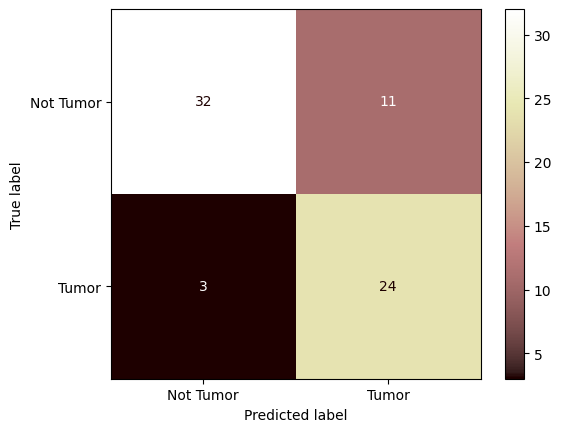

In [23]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Tumor', 'Tumor'])
disp.plot(cmap=plt.cm.pink)

print(f"\nAccuracy score: {accuracy_score(y_true=y_test, y_pred=y_pred)}")